# 🧠 Mental Wellness — Health Floor Segmentation
> Spectrum-based approach using HealthScore quantile floors.
> More honest and interpretable than forcing KMeans on naturally continuous wellness data.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded")

✅ All libraries loaded


## 2. Load Data

In [2]:
df = pd.read_csv('mental_wellness.csv')
print("Shape:", df.shape)
df.head()

Shape: (1485, 5)


,Sleep_Hours,Sleep_Quality,Physical_Activity_Min,Diet_Quality,Stress_Level
0,10.0,0.0,41,1.0,3
1,5.7,2.0,36,1.0,8
2,7.5,2.0,7,1.0,8
3,5.6,2.0,35,0.0,5
4,7.3,0.0,29,0.0,1


## 3. Select & Inspect Features

In [3]:
cols = [
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity_Min",
    "Diet_Quality",
    "Stress_Level"
]

df = df[cols].copy()
print("Columns selected:", cols)
print()
df.describe().round(2)

Columns selected: ['Sleep_Hours', 'Sleep_Quality', 'Physical_Activity_Min', 'Diet_Quality', 'Stress_Level']



,Sleep_Hours,Sleep_Quality,Physical_Activity_Min,Diet_Quality,Stress_Level
count,1485.00,1485.00,1485.00,1485.00,1485.00
mean,6.96,1.27,29.62,0.79,4.07
std,1.43,1.03,14.71,0.58,2.17
min,3.00,0.00,0.00,0.00,1.00
25%,6.00,0.00,20.00,0.00,2.00
50%,7.00,1.00,29.00,1.00,4.00
75%,7.90,2.00,39.00,1.00,6.00
max,10.00,3.00,80.00,2.00,10.00


## 4. Clean — Drop Duplicates & Nulls

In [4]:
before = len(df)
df = df.drop_duplicates().dropna()
print(f"Rows before: {before}  |  After cleaning: {len(df)}  |  Dropped: {before - len(df)}")

Rows before: 1485  |  After cleaning: 1485  |  Dropped: 0


## 5. Encode Categorical Columns
> Using separate OrdinalEncoder per column to prevent label leakage.

In [5]:
sleep_enc = OrdinalEncoder()
diet_enc  = OrdinalEncoder()

df["Sleep_Quality"] = sleep_enc.fit_transform(df[["Sleep_Quality"]])
df["Diet_Quality"]  = diet_enc.fit_transform(df[["Diet_Quality"]])

print("Sleep_Quality categories:", sleep_enc.categories_[0].tolist())
print("Diet_Quality categories :", diet_enc.categories_[0].tolist())
df.head()

Sleep_Quality categories: [0.0, 1.0, 2.0, 3.0]
Diet_Quality categories : [0.0, 1.0, 2.0]


,Sleep_Hours,Sleep_Quality,Physical_Activity_Min,Diet_Quality,Stress_Level
0,10.0,0.0,41,1.0,3
1,5.7,2.0,36,1.0,8
2,7.5,2.0,7,1.0,8
3,5.6,2.0,35,0.0,5
4,7.3,0.0,29,0.0,1


## 6. Remove Outliers — IQR Method

In [6]:
num_cols = ["Sleep_Hours", "Physical_Activity_Min", "Stress_Level"]

Q1  = df[num_cols].quantile(0.25)
Q3  = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask     = ~((df[num_cols] < lower) | (df[num_cols] > upper)).any(axis=1)
df_clean = df[mask].reset_index(drop=True)

print(f"Rows before outlier removal : {len(df)}")
print(f"Rows after  outlier removal : {len(df_clean)}")
print(f"Outliers removed            : {len(df) - len(df_clean)}")

Rows before outlier removal : 1485
Rows after  outlier removal : 1465
Outliers removed            : 20


## 7. Scale All Features

In [7]:
X = df_clean[cols].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=cols)

print("Scaling complete.")
print("Mean (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Std  (should be ~1):", X_scaled.std(axis=0).round(3))

Scaling complete.
Mean (should be ~0): [0. 0. 0. 0. 0.]
Std  (should be ~1): [1. 1. 1. 1. 1.]


## 8. Compute HealthScore
> Weighted formula using scaled values so no single feature dominates.

| Feature | Weight | Reason |
|---|---|---|
| Sleep_Hours | +1 | Core recovery metric |
| Sleep_Quality | +2 | Quality matters more than hours |
| Diet_Quality | +2 | Strong predictor of wellness |
| Physical_Activity_Min | +1 | Activity duration |
| Stress_Level | -2 | Stress is the strongest negative driver |

In [8]:
df_clean["HealthScore"] = (
      X_scaled_df["Sleep_Hours"]            * 1
    + X_scaled_df["Sleep_Quality"]          * 2
    + X_scaled_df["Diet_Quality"]           * 2
    + X_scaled_df["Physical_Activity_Min"]  * 1
    - X_scaled_df["Stress_Level"]           * 2
)

print("HealthScore distribution:")
print(df_clean["HealthScore"].describe().round(3))

HealthScore distribution:
count    1465.000
mean        0.000
std         3.833
min       -11.987
25%        -2.786
50%         0.018
75%         2.616
max        14.286
Name: HealthScore, dtype: float64


## 9. HealthScore Distribution

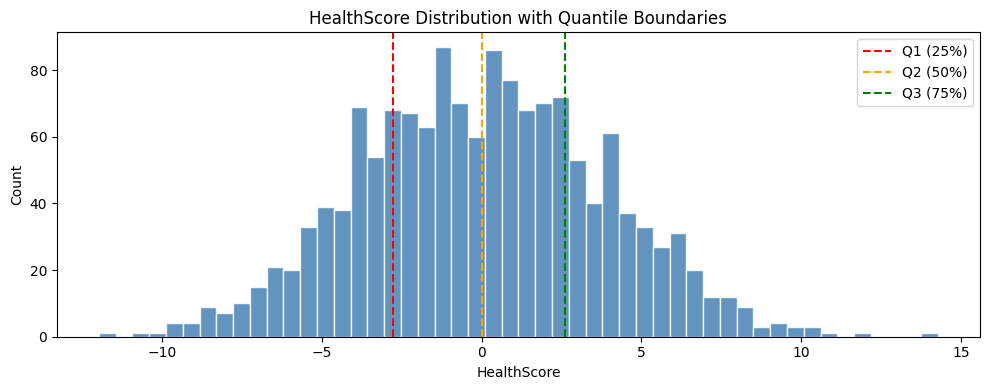

In [9]:
plt.figure(figsize=(10, 4))
plt.hist(df_clean["HealthScore"], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(df_clean["HealthScore"].quantile(0.25), color='red',    linestyle='--', label='Q1 (25%)')
plt.axvline(df_clean["HealthScore"].quantile(0.50), color='orange', linestyle='--', label='Q2 (50%)')
plt.axvline(df_clean["HealthScore"].quantile(0.75), color='green',  linestyle='--', label='Q3 (75%)')
plt.xlabel("HealthScore")
plt.ylabel("Count")
plt.title("HealthScore Distribution with Quantile Boundaries")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Assign Health Floors via Quantile Binning
> 4 equal-sized floors based on HealthScore.
> This is more honest than KMeans — the data is a continuous spectrum, not discrete clusters.

In [10]:
FLOOR_LABELS = [
    "🔴 Floor 0 — At Risk",
    "🟠 Floor 1 — Below Average",
    "🟡 Floor 2 — Average",
    "🟢 Floor 3 — Healthy"
]

df_clean["HealthFloor"], bins = pd.qcut(
    df_clean["HealthScore"],
    q=4,
    labels=FLOOR_LABELS,
    retbins=True
)

# Also keep numeric version for plotting
df_clean["FloorNum"] = pd.qcut(
    df_clean["HealthScore"],
    q=4,
    labels=False
)

print("Floor distribution:")
print(df_clean["HealthFloor"].value_counts().sort_index())
print()
print("Quantile boundaries:", bins.round(3))

Floor distribution:
HealthFloor
🔴 Floor 0 — At Risk          367
🟠 Floor 1 — Below Average    366
🟡 Floor 2 — Average          366
🟢 Floor 3 — Healthy          366
Name: count, dtype: int64

Quantile boundaries: [-11.987  -2.786   0.018   2.616  14.286]


## 11. Floor Distribution

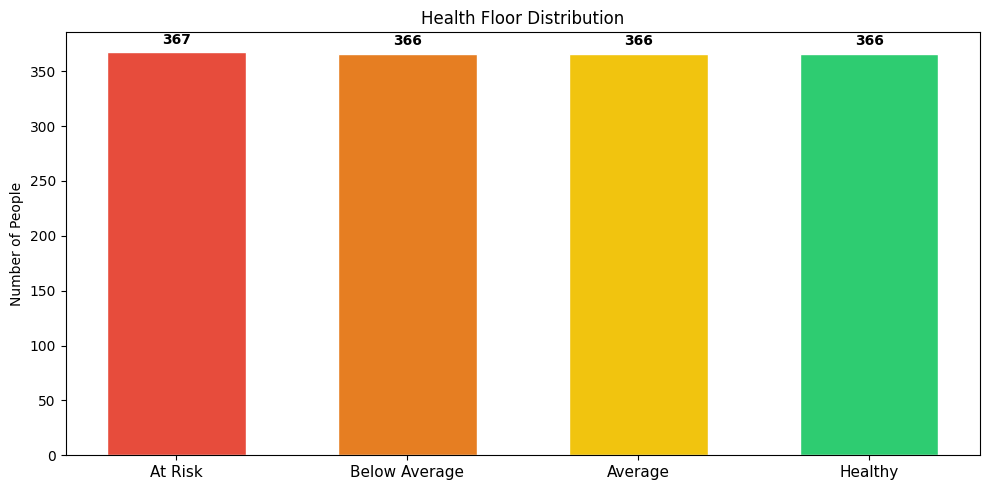

In [22]:
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

floor_counts = df_clean["HealthFloor"].value_counts().reindex(FLOOR_LABELS)  # ← changed

plt.figure(figsize=(10, 5))
bars = plt.bar(range(4), floor_counts.values, color=colors, edgecolor='white', width=0.6)

for bar, count in zip(bars, floor_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.xticks(range(4), ["At Risk", "Below Average", "Average", "Healthy"], fontsize=11)
plt.ylabel("Number of People")
plt.title("Health Floor Distribution")
plt.tight_layout()
plt.show()

## 12. PCA — Dimensionality Reduction for Visualization

In [12]:
X_floor = df_clean[[
    "HealthScore",
    "Sleep_Hours",
    "Physical_Activity_Min",
    "Sleep_Quality",
    "Diet_Quality"
]].values

X_floor_scaled = StandardScaler().fit_transform(X_floor)

pca = PCA(n_components=3, random_state=42)
X_3D = pca.fit_transform(X_floor_scaled)

df_clean["C1"] = X_3D[:, 0]
df_clean["C2"] = X_3D[:, 1]
df_clean["C3"] = X_3D[:, 2]

print("Explained variance per component:", pca.explained_variance_ratio_.round(4))
print("Total explained variance        :", pca.explained_variance_ratio_.sum().round(3))

Explained variance per component: [0.372  0.2123 0.2031]
Total explained variance        : 0.787


## 13. 2D PCA Projection — Health Floors

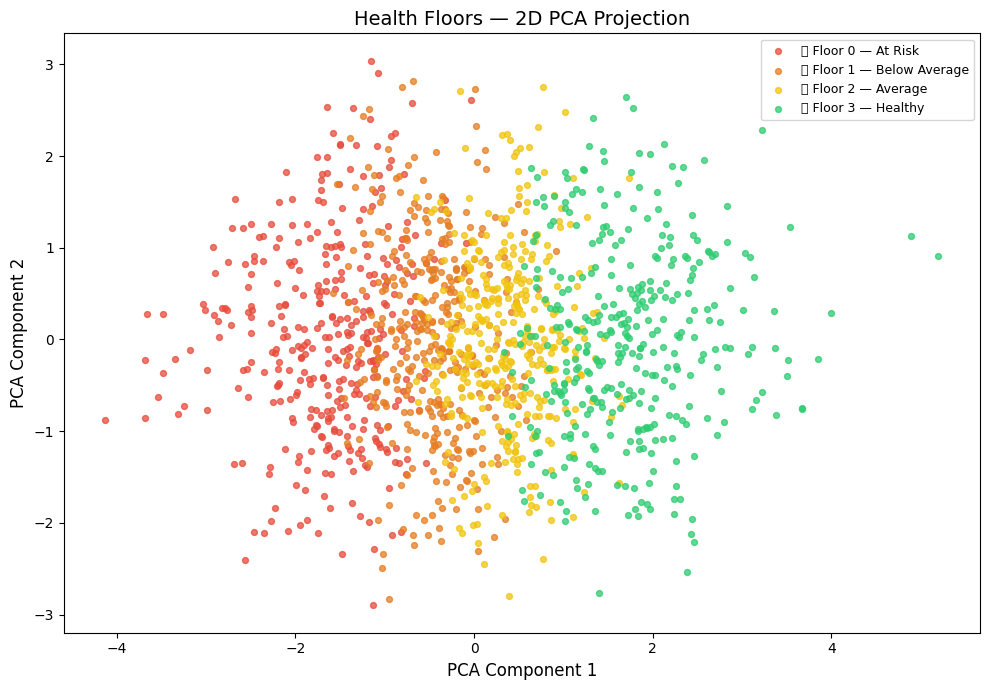

In [13]:
color_map = {
    "🔴 Floor 0 — At Risk"         : '#e74c3c',
    "🟠 Floor 1 — Below Average"   : '#e67e22',
    "🟡 Floor 2 — Average"         : '#f1c40f',
    "🟢 Floor 3 — Healthy"         : '#2ecc71'
}

plt.figure(figsize=(10, 7))

for floor, color in color_map.items():
    mask = df_clean["HealthFloor"] == floor
    plt.scatter(
        df_clean.loc[mask, "C1"],
        df_clean.loc[mask, "C2"],
        c=color, label=floor, s=18, alpha=0.75
    )

plt.xlabel("PCA Component 1", fontsize=12)
plt.ylabel("PCA Component 2", fontsize=12)
plt.title("Health Floors — 2D PCA Projection", fontsize=14)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 14. 3D Interactive Visualization — Health Floors

In [14]:
color_seq = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

fig = px.scatter_3d(
    df_clean,
    x="C1", y="C2", z="C3",
    color="HealthFloor",
    color_discrete_sequence=color_seq,
    title="4 Health Floors — Stratified Segmentation",
    labels={"HealthFloor": "Health Floor"}
)
fig.update_traces(marker=dict(size=3, opacity=0.8))
fig.update_layout(legend=dict(font=dict(size=10)))
fig.show()

## 15. HealthScore Range per Floor

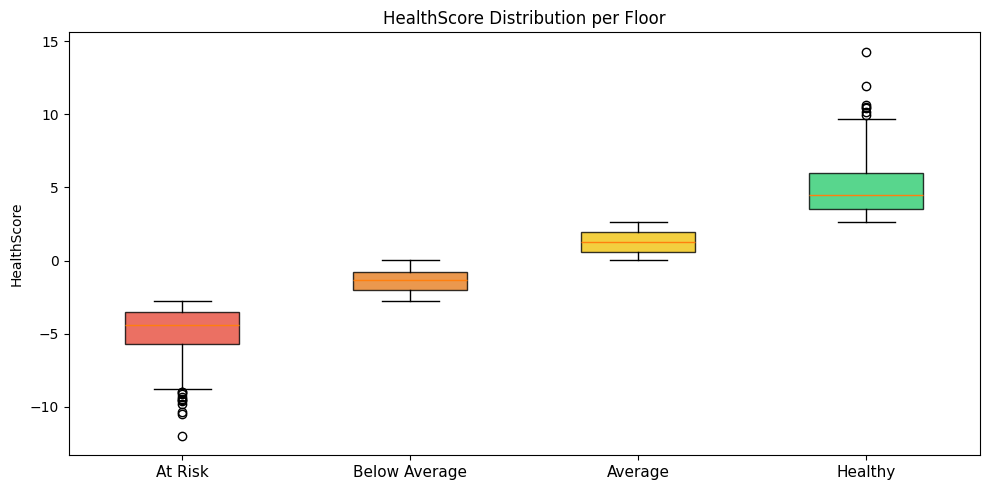

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

data_by_floor = [
    df_clean.loc[df_clean["HealthFloor"] == label, "HealthScore"].values
    for label in FLOOR_LABELS
]

bp = ax.boxplot(data_by_floor, patch_artist=True, widths=0.5)

for patch, color in zip(bp['boxes'], ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticklabels(["At Risk", "Below Average", "Average", "Healthy"], fontsize=11)
ax.set_ylabel("HealthScore")
ax.set_title("HealthScore Distribution per Floor")
plt.tight_layout()
plt.show()

## 16. Silhouette Evaluation
> Even with quantile floors, we measure how well-separated the groups are.

In [16]:
labels     = df_clean["FloorNum"].values
sil_score  = silhouette_score(X_floor_scaled, labels)
sil_samples= silhouette_samples(X_floor_scaled, labels)

print(f"Silhouette Score  : {sil_score:.4f}")
print(f"Average silhouette: {np.mean(sil_samples):.4f}")
print(f"Min silhouette    : {np.min(sil_samples):.4f}")
print(f"Max silhouette    : {np.max(sil_samples):.4f}")

print("\nPer-floor silhouette:")
for i, label in enumerate(FLOOR_LABELS):
    avg = np.mean(sil_samples[labels == i])
    bar = '█' * int(avg * 40)
    print(f"  {label}: {avg:.4f}  {bar}")

Silhouette Score  : 0.0655
Average silhouette: 0.0655
Min silhouette    : -0.1861
Max silhouette    : 0.2859

Per-floor silhouette:
  🔴 Floor 0 — At Risk: 0.0970  ███
  🟠 Floor 1 — Below Average: 0.0168  
  🟡 Floor 2 — Average: 0.0434  █
  🟢 Floor 3 — Healthy: 0.1048  ████


## 17. Health Floor Profiles — What Each Floor Looks Like

In [21]:
# Reverse-scale directly from df_clean to avoid row mismatch
df_original = pd.DataFrame(
    scaler.inverse_transform(df_clean[cols].values),
    columns=cols
)
df_original["HealthFloor"] = df_clean["HealthFloor"].values
df_original["HealthScore"] = df_clean["HealthScore"].values

profile = df_original.groupby("HealthFloor")[cols + ["HealthScore"]].mean().round(2)
print("\n📊 Average profile per Health Floor:")
print(profile.to_string())


📊 Average profile per Health Floor:
                           Sleep_Hours  Sleep_Quality  Physical_Activity_Min  Diet_Quality  Stress_Level  HealthScore
HealthFloor                                                                                                          
🔴 Floor 0 — At Risk              15.78           1.88                 392.26          1.06         16.57        -4.84
🟠 Floor 1 — Below Average        16.56           2.35                 434.36          1.20         13.85        -1.36
🟡 Floor 2 — Average              17.06           2.73                 450.60          1.29         11.36         1.28
🟢 Floor 3 — Healthy              17.95           3.30                 505.08          1.48          9.65         4.93


## 18. Radar Chart — Floor Profiles

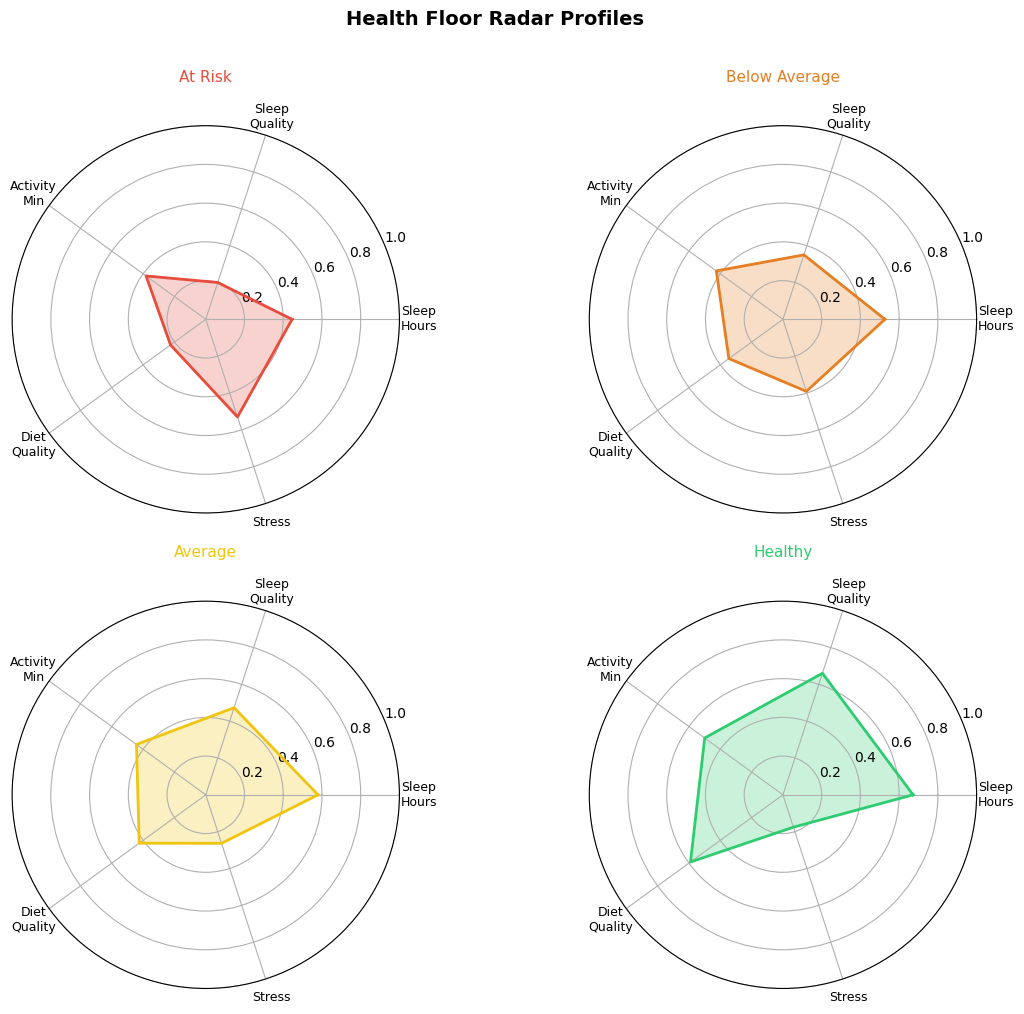

In [18]:
import math

features  = ["Sleep_Hours", "Sleep_Quality", "Physical_Activity_Min", "Diet_Quality", "Stress_Level"]
n         = len(features)
angles    = [i * 2 * math.pi / n for i in range(n)] + [0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw=dict(polar=True))
axes      = axes.flatten()
colors    = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

for idx, (label, color) in enumerate(zip(FLOOR_LABELS, colors)):
    ax     = axes[idx]
    row    = profile.loc[label, features].values
    # normalize 0-1
    normed = (row - df_original[features].min().values) / (df_original[features].max().values - df_original[features].min().values + 1e-9)
    values = list(normed) + [normed[0]]

    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(["Sleep\nHours", "Sleep\nQuality", "Activity\nMin", "Diet\nQuality", "Stress"], fontsize=9)
    ax.set_title(label.split('—')[1].strip(), color=color, fontsize=11, pad=15)
    ax.set_ylim(0, 1)

plt.suptitle("Health Floor Radar Profiles", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 19. Feature Heatmap — Floors vs Features

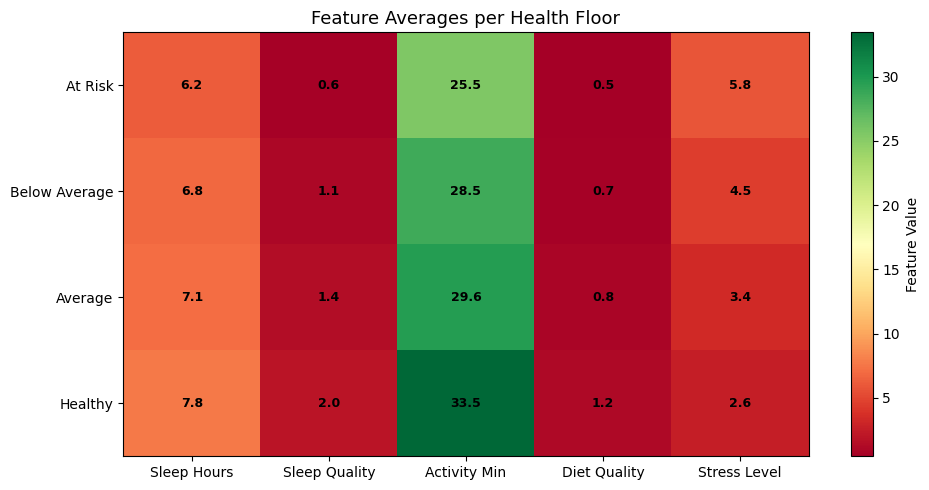

In [19]:
import matplotlib.colors as mcolors

heatmap_data = profile[features].copy()

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto')

ax.set_xticks(range(len(features)))
ax.set_xticklabels(["Sleep Hours", "Sleep Quality", "Activity Min", "Diet Quality", "Stress Level"], fontsize=10)
ax.set_yticks(range(4))
ax.set_yticklabels(["At Risk", "Below Average", "Average", "Healthy"], fontsize=10)
ax.set_title("Feature Averages per Health Floor", fontsize=13)

for i in range(4):
    for j in range(len(features)):
        ax.text(j, i, f"{heatmap_data.values[i,j]:.1f}",
                ha='center', va='center', fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax, label="Feature Value")
plt.tight_layout()
plt.show()

## 20. Export Results

In [20]:
export_df = df_clean[cols + ["HealthScore", "HealthFloor", "FloorNum", "C1", "C2", "C3"]].copy()
export_df.to_csv('Mental_Wellness_Floors.csv', index=False)
print(f"✅ Exported {len(export_df)} rows to Mental_Wellness_Floors.csv")
print("Columns:", export_df.columns.tolist())

✅ Exported 1465 rows to Mental_Wellness_Floors.csv
Columns: ['Sleep_Hours', 'Sleep_Quality', 'Physical_Activity_Min', 'Diet_Quality', 'Stress_Level', 'HealthScore', 'HealthFloor', 'FloorNum', 'C1', 'C2', 'C3']


## 21. Summary & Interpretation

| Floor | Label | Meaning | Action |
|---|---|---|---|
| 0 | 🔴 At Risk | Low sleep, poor diet, high stress | Immediate intervention |
| 1 | 🟠 Below Average | Moderate issues across features | Lifestyle coaching |
| 2 | 🟡 Average | Decent habits, room to improve | Maintenance programs |
| 3 | 🟢 Healthy | Good sleep, diet, activity, low stress | Keep it up! |